In [1]:
#!pip install sqlalchemy pandas mlxtend seaborn
%load_ext autoreload
%autoreload 2

# Verbimallid apriori

## Ülesande kirjeldus Svenilt
1. Trandaktsioonide sisu filtreerimine
    - Kadrit ei huvita vebile alluvad kirjavahemärgid
    - Kadrit ei huvita verbile alluv kõrvallause.
      (ma sõin putru ja vaatasin televiisorit) 
      Vastav alampuu on spetsiifilise deprel nimega (sinu näites cc ja veel ka conj)
      Kontrolli seda ise vaadates erinevaid liitlauseid läbi. Kadri saab sind selles osas aidata
   - Vaata et transaktsiooni ei jääks ühendverbi liite osa (kirjutas maha --> maha), sest see on müra

2. Transaktsiooni item-ite moodustamine
    - Kadri meelest pole ainuse ja mitmuse eristamine oluline välja arvatud subject/objekt tippudes
    - Item peaks olema deprel + form. 
      Sul on mingit tipud deprel + form1, form2 kuidas see tekkida sai
      Näiteks {'deprel': 'nsubj', 'feats': 'com,nom,sg'} -- kas see on mitmene morf analüüs? Kui jah, kas sa saad siis com | nom kasutada
- sõnavormide lisamine item-i sisse. 
Võiks olla mingi lävend, et kui sõnavorm on antud deprel-i all sagedamini kui 20% siis jääb see ka alles
magas und --> und on obj ja peaaegfu ainus võimalik obj verbiga magama


3. Itemset mining. Sellele on vaja peale visata almost-closed set filter
 
Sa hakkad tulemusi vaatama kõige pikematest alamhulkadest


Olgu sul pikk alamhulk X sagedusega t_X ja olgu Y selle ühe itemiga vähem hulk st Y + {a} = X 
Siis tuleb hulk Y kustutada kui selle sagedus t_y >= t_x - delta, kus delta on mingi lävend
Standard juhul on delta=0, aga meie rakenduses võiks delta olla 2-5% kui sa mõõdad sagedust protsentides


Kui sa nii, kontrollid elementide arvu järgi tagurpidiselt järjestatud hulki, saad kompaktse esituse, mida meil vaja on


4. Tulemuse esitus


Graafiline heatmap, Pane allesjäänud hulgad 0/1 kodeeringus heatmapile


Järjestus peaks olema SUB, OBJ, OBL1, ...OBLx, muud
Kadri annab täpse järjestuse


## TODO!

* Täpsustada ignoreeritavate deprelide nimekirja. Hetkel: ["cc", "conj", "punct", "mark", "aux"] ja compound:prt kui compound=None
  
*  Järjestada liikmed Kadri etteantud järjekorras (kas sõnad näidetes tuleb järestada ka vastavalt?).
*  Kaaluda kirjavahemärkide jne müra eemaldamist andmestikust. 
*  Parandada apriori tulemuse filtreerimine protsendi järgi


# Algseadistamine

In [2]:
import pandas as pd
import sys
sys.path.append('../../')
from paths import PATH_COMMON_CODE, PATH_ROOT
sys.path.append(PATH_COMMON_CODE)
from apriori import V30

pd.set_option('display.max_colwidth', 0)

v30 = V30(
    PATH_ROOT + "/databases/v30_data.db",
    form_treshold_percent = 20,
    form_treshold_count = 5,
    apriori_min_support=0.05,
    apriori_treshold_delta = 0.03,
    apriori_treshold_percent=50,
    datarows_treshold=100000
    )

## armastama

************************************************ armastama   ************************************************
Ridu analüüsimiseks: 19225
apriori min_support: 0.05
delta: 0.03
percent: 50


,support,itemsets,example,drop,drop_reason,length
4,0.654980,"((OBJ, part, ))",teineteist,False,,1
2,0.608010,"((NSUBJ, nom, ))",epp,False,,1
12,0.374460,"((OBJ, part, ), (NSUBJ, nom, ))",kes sind,False,,2
0,0.305956,"((ADVMOD, , ))",ju nii,False,,1
5,0.233290,"((XCOMP, , ))",väänata,False,,1
8,0.202185,"((ADVMOD, , ), (OBJ, part, ))",naist nüüd rohkem,False,,2
6,0.191053,"((ADVMOD, , ), (NSUBJ, nom, ))",raha ikka,False,,2
13,0.167906,"((XCOMP, , ), (NSUBJ, nom, ))",inimene võrrelda,False,,2
3,0.166242,"((NSUBJ, nom, ma))",ma,True,(row 14) delta: abs(0.1401 - 0.1662) < 0.03 %: (0.1662-0.1401)/0.1401*100<50,1
14,0.140078,"((NSUBJ, nom, ma), (OBJ, part, ))",ma olevikku,False,,2


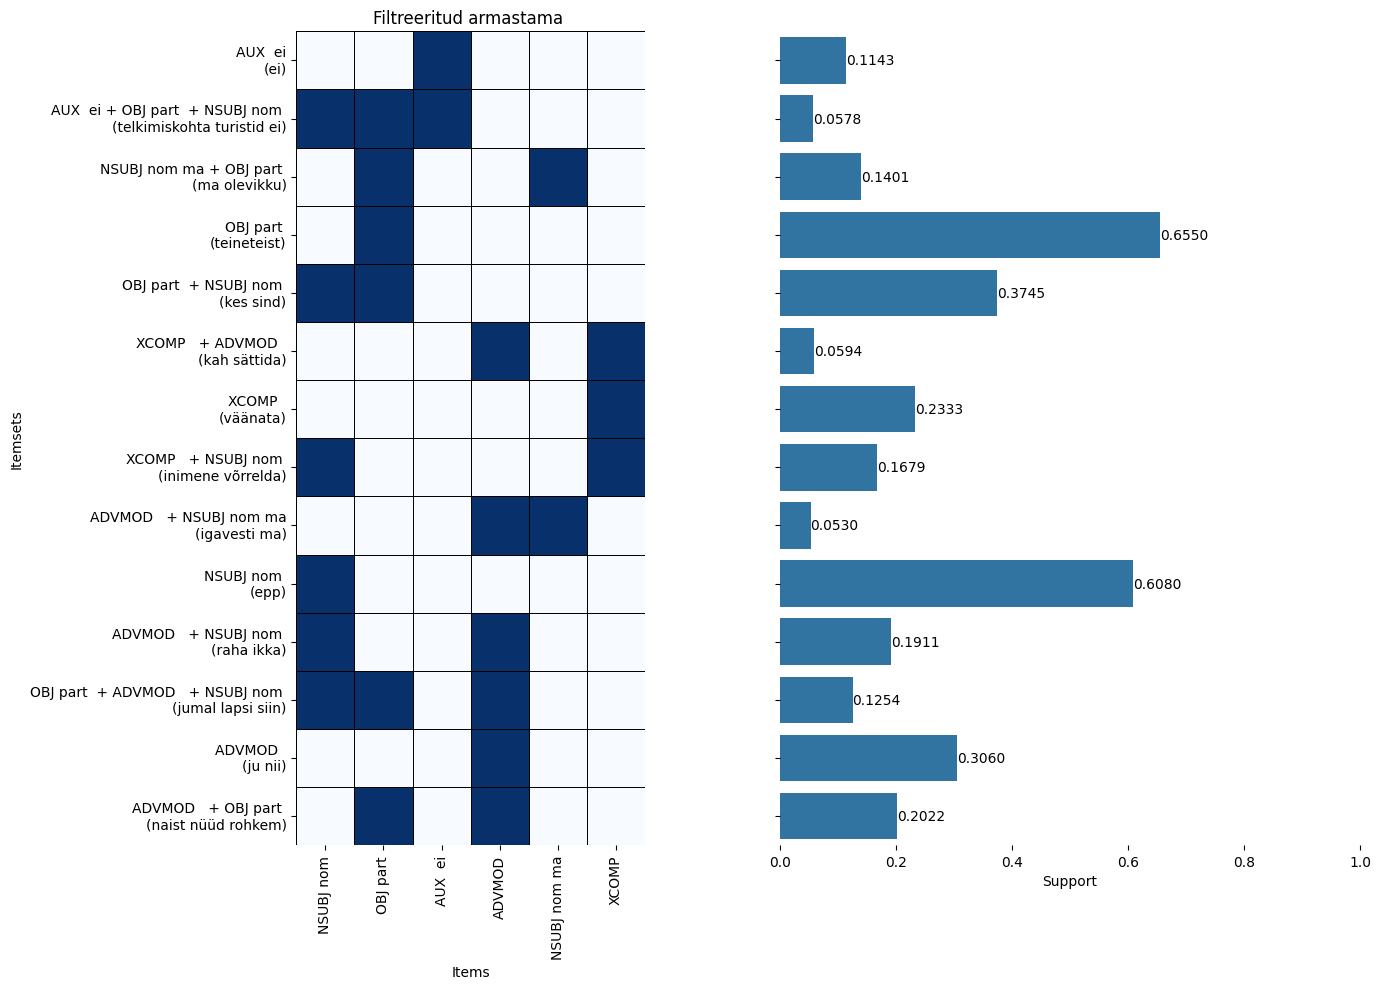

CPU times: user 42.8 s, sys: 15.7 s, total: 58.4 s
Wall time: 1min 29s


In [3]:
%%time
result = v30.make_all(verb='armastama', verb_compound='', examples=True)


## hüppama alla



************************************************ hüppama  alla ************************************************
Ridu analüüsimiseks: 535
apriori min_support: 0.05
delta: 0.03
percent: 50


,support,itemsets,example,drop,drop_reason,length
2,0.571963,"((NSUBJ, nom, ))",inimesed,False,,1
5,0.459813,"((OBL, el, ))",aknast,False,,1
3,0.366355,"((OBL, abl, ))",rõdult,False,,1
16,0.265421,"((OBL, el, ), (NSUBJ, nom, ))",ene kaldast,False,,2
1,0.241121,"((ADVMOD, , ))",eile,False,,1
14,0.228037,"((OBL, abl, ), (NSUBJ, nom, ))",barinski autokatuselt,False,,2
6,0.162617,"((OBL, gen, ))",versiooni,False,,1
4,0.158879,"((OBL, ad, ))",õhtul,True,(row 15) delta: abs(0.1308 - 0.1589) < 0.03 %: (0.1589-0.1308)/0.1308*100<50,1
15,0.130841,"((OBL, ad, ), (NSUBJ, nom, ))",põlvamaal laupäeval noormees,False,,2
7,0.128972,"((OBL, in, ))",paanikas,False,,1


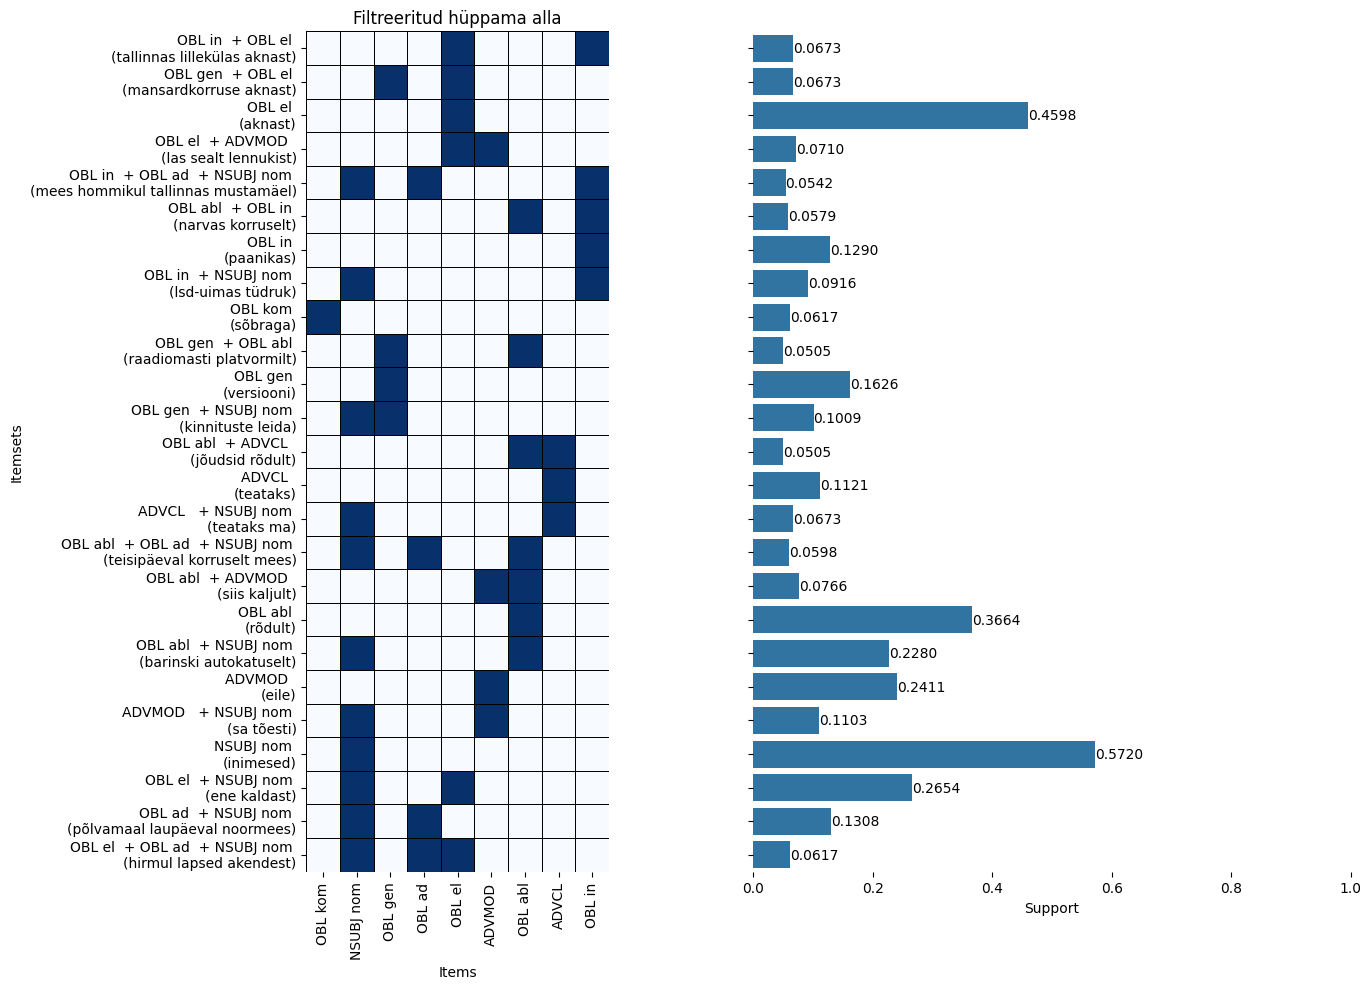

CPU times: user 1min 5s, sys: 28.9 s, total: 1min 34s
Wall time: 2min 28s


In [4]:
%%time

result = v30.make_all(verb='hüppama', verb_compound='alla', examples=True)

## sadama

************************************************ sadama   ************************************************
Ridu analüüsimiseks: 5809
apriori min_support: 0.05
delta: 0.03
percent: 50


,support,itemsets,example,drop,drop_reason,length
0,0.446548,"((ADVMOD, , ))",kohati,False,,1
4,0.252711,"((NSUBJ, part, vihma))",vihma,False,,1
5,0.209330,"((OBL, ad, ))",päeval,False,,1
2,0.186607,"((NSUBJ, part, ))",kriitikanooli,False,,1
9,0.174729,"((OBL, in, ))",spa's,False,,1
3,0.169048,"((NSUBJ, part, lund))",lund,False,,1
1,0.138750,"((NSUBJ, nom, ))",lumi,False,,1
14,0.102599,"((ADVMOD, , ), (NSUBJ, part, vihma))",väljas vihma,False,,2
8,0.097951,"((OBL, gen, ))",etenduste,False,,1
15,0.083147,"((ADVMOD, , ), (OBL, ad, ))",varahommikul paiguti,False,,2


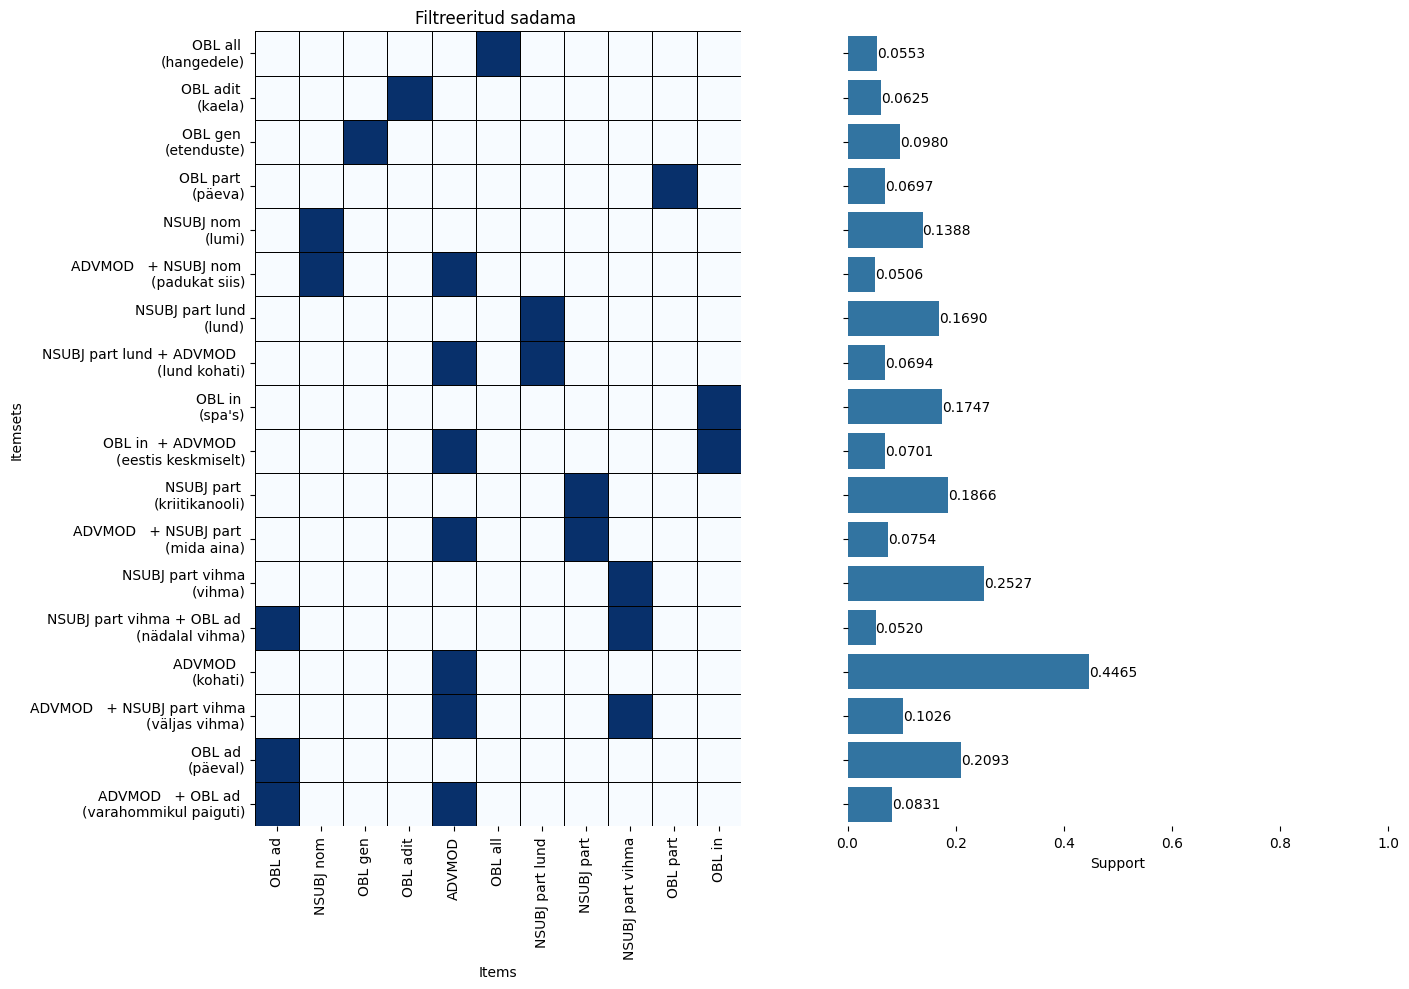

In [5]:
result = v30.make_all(verb='sadama', verb_compound='', examples=True)

## venitama

************************************************ venitama   ************************************************
Ridu analüüsimiseks: 1930
apriori min_support: 0.05
delta: 0.03
percent: 50


,support,itemsets,example,drop,drop_reason,length
2,0.694301,"((NSUBJ, nom, ))",firma,False,,1
1,0.338342,"((ADVMOD, , ))",kahtlemata,False,,1
5,0.316062,"((OBJ, part, ))",kinnisvaratehinguid,False,,1
9,0.240415,"((OBL, kom, ))",tagastamisega,False,,1
12,0.230570,"((ADVMOD, , ), (NSUBJ, nom, ))",kes endiselt,False,,2
16,0.184974,"((NSUBJ, nom, ), (OBJ, part, ))",osa olijaid,False,,2
19,0.182902,"((OBL, kom, ), (NSUBJ, nom, ))",täitevvõim lahendamisega,False,,2
3,0.141969,"((OBJ, gen, ))",kontrolli,False,,1
0,0.124870,"((ADVCL, , ))",pikendada,False,,1
13,0.101554,"((ADVMOD, , ), (OBJ, part, ))",ainult asja,False,,2


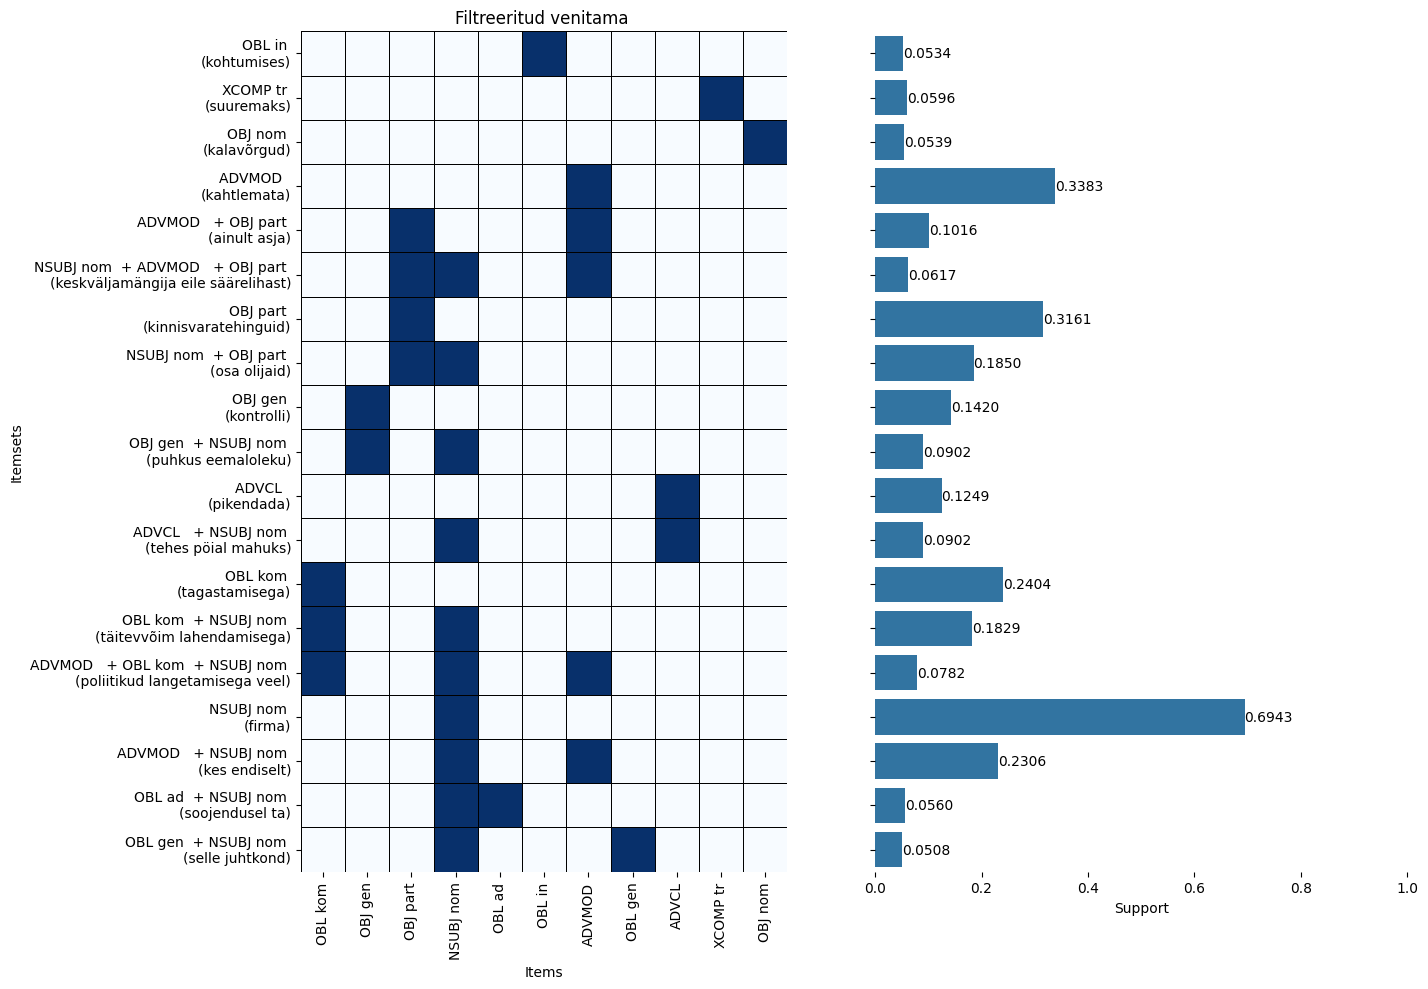

CPU times: user 53.7 s, sys: 29.4 s, total: 1min 23s
Wall time: 2min 29s


In [6]:
%%time
result = v30.make_all(verb='venitama', verb_compound='', examples=True)


************************************************ magama   ************************************************
Ridu analüüsimiseks: 11283
apriori min_support: 0.05
delta: 0.03
percent: 50


,support,itemsets,example,drop,drop_reason,length
4,0.677568,"((NSUBJ, nom, ))",dodge,False,,1
1,0.456616,"((ADVMOD, , ))",küljeli,False,,1
11,0.302668,"((ADVMOD, , ), (NSUBJ, nom, ))",ma üksi,False,,2
3,0.155278,"((AUX, , ei))",ei,False,,1
7,0.149517,"((OBL, in, ))",vanalinnas,False,,1
12,0.119826,"((AUX, , ei), (NSUBJ, nom, ))",sa ei,False,,2
5,0.112293,"((OBL, ad, ))",ajal,False,,1
6,0.106355,"((OBL, gen, ))",tee,False,,1
15,0.094390,"((OBL, in, ), (NSUBJ, nom, ))",kes köögis pappkastides,False,,2
8,0.076930,"((OBL, kom, ))",meelega,True,(row 16) delta: abs(0.0556 - 0.0769) < 0.03 %: (0.0769-0.0556)/0.0556*100<50,1


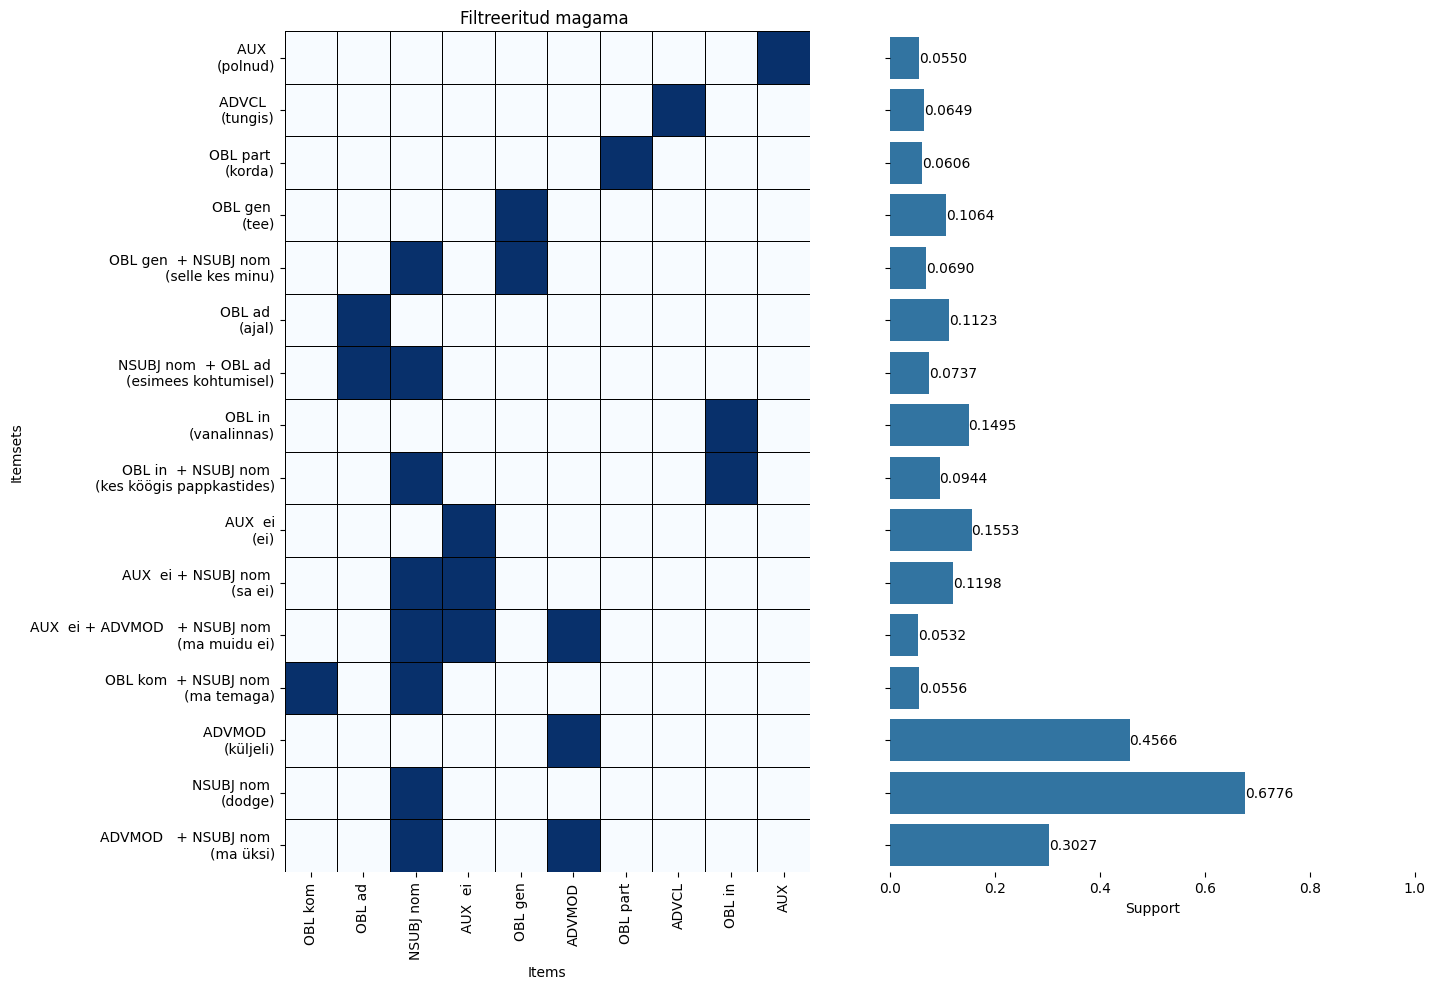

CPU times: user 45.9 s, sys: 23.1 s, total: 1min 9s
Wall time: 2min 15s


In [7]:
%%time
result = v30.make_all(verb='magama', verb_compound='', examples=True)


************************************************ minema  None ************************************************
Ridu analüüsimiseks: 351172
	liiga palju ridu analüüsimiseks: 351172
	analüüsitakse 100000 juhuslikku
apriori min_support: 0.05
delta: 0.03
percent: 50


,support,itemsets,example,drop,drop_reason,length
3,0.60717,"((NSUBJ, nom, ))",müük,False,,1
1,0.42307,"((ADVMOD, , ))",nüüd nii aga,False,,1
18,0.24613,"((ADVMOD, , ), (NSUBJ, nom, ))",saund ka,False,,2
14,0.13811,"((XCOMP, ill, ))",maksma,False,,1
7,0.13320,"((OBL, all, ))",neile,False,,1
5,0.13192,"((OBL, ad, ))",lauluväljakul,False,,1
9,0.12927,"((OBL, gen, ))",tjuninile,False,,1
0,0.11017,"((ADVCL, , ))",raiuti,False,,1
15,0.10334,"((XCOMP, tr, ))",nõrgaks,False,,1
6,0.09364,"((OBL, adit, ))",tallinna,False,,1


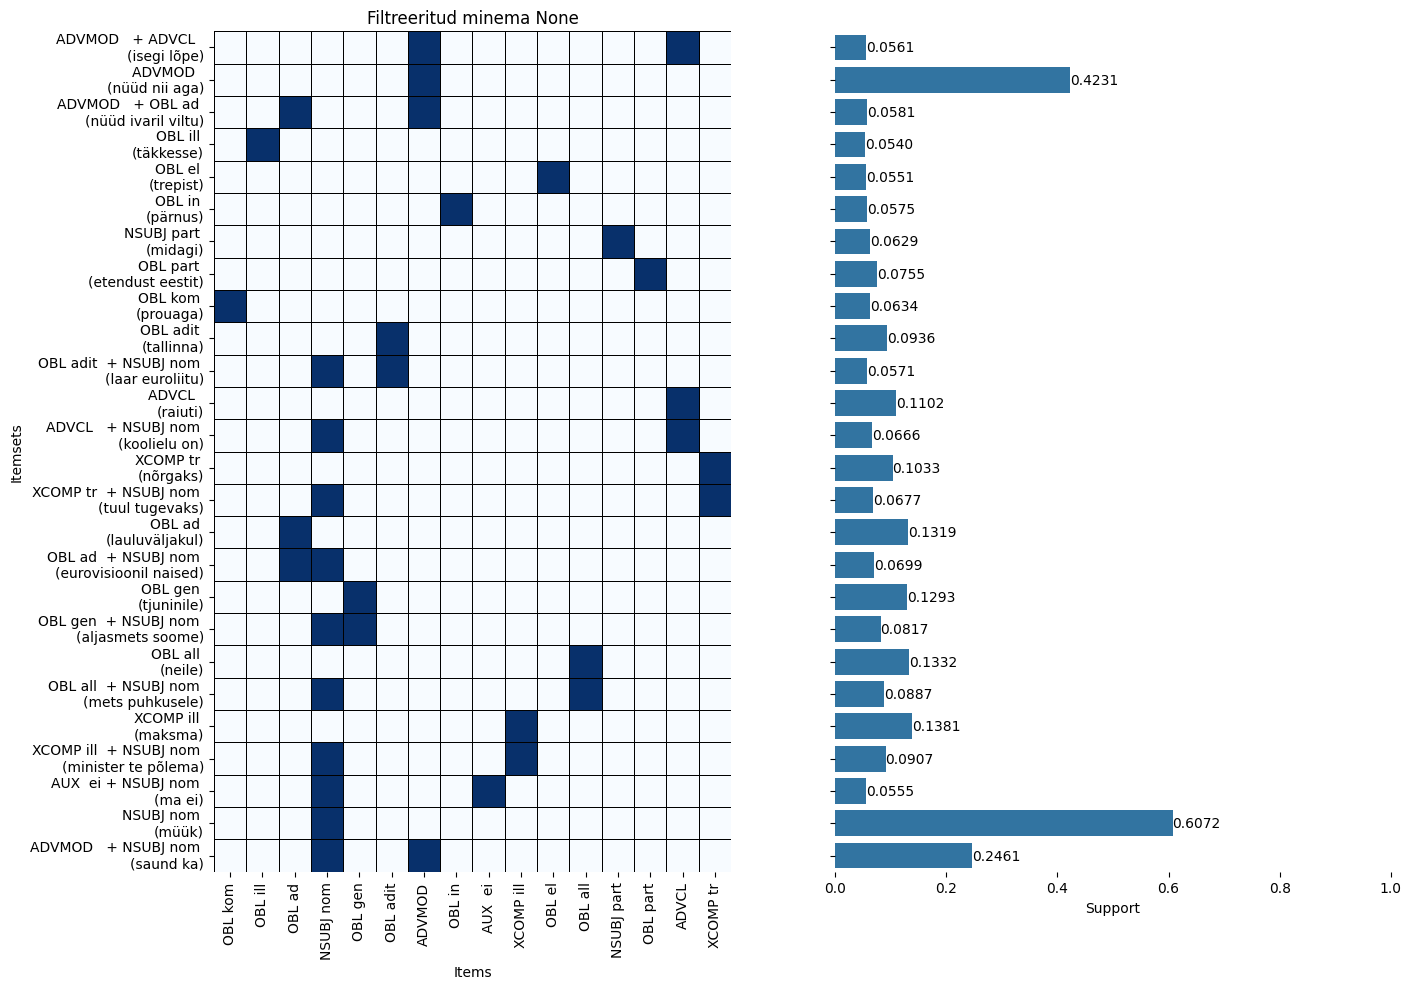

CPU times: user 1min 4s, sys: 23.2 s, total: 1min 27s
Wall time: 2min 15s


In [8]:
%%time
result = v30.make_all(verb='minema', verb_compound=None, examples=True)


************************************************ torkama   ************************************************
Ridu analüüsimiseks: 4538
apriori min_support: 0.05
delta: 0.03
percent: 50


,support,itemsets,example,drop,drop_reason,length
4,0.664610,"((NSUBJ, nom, ))",nooruk,False,,1
12,0.449537,"((OBL, adit, silma))",silma,False,,1
1,0.402600,"((ADVMOD, , ))",ikka,False,,1
29,0.300353,"((OBL, adit, silma), (NSUBJ, nom, ))",päike silma,False,,2
21,0.277215,"((ADVMOD, , ), (NSUBJ, nom, ))",linnaauto kõikjal,False,,2
22,0.208021,"((ADVMOD, , ), (OBL, adit, silma))",esialgu silma,False,,2
0,0.155355,"((ADVCL, , ))",vaadates,False,,1
14,0.147642,"((OBL, gen, ))",töökäte,False,,1
38,0.146100,"((ADVMOD, , ), (OBL, adit, silma), (NSUBJ, nom, ))",see iseäranis silma,False,,3
6,0.132878,"((OBJ, gen, ))",jälgimiskiibi,False,,1


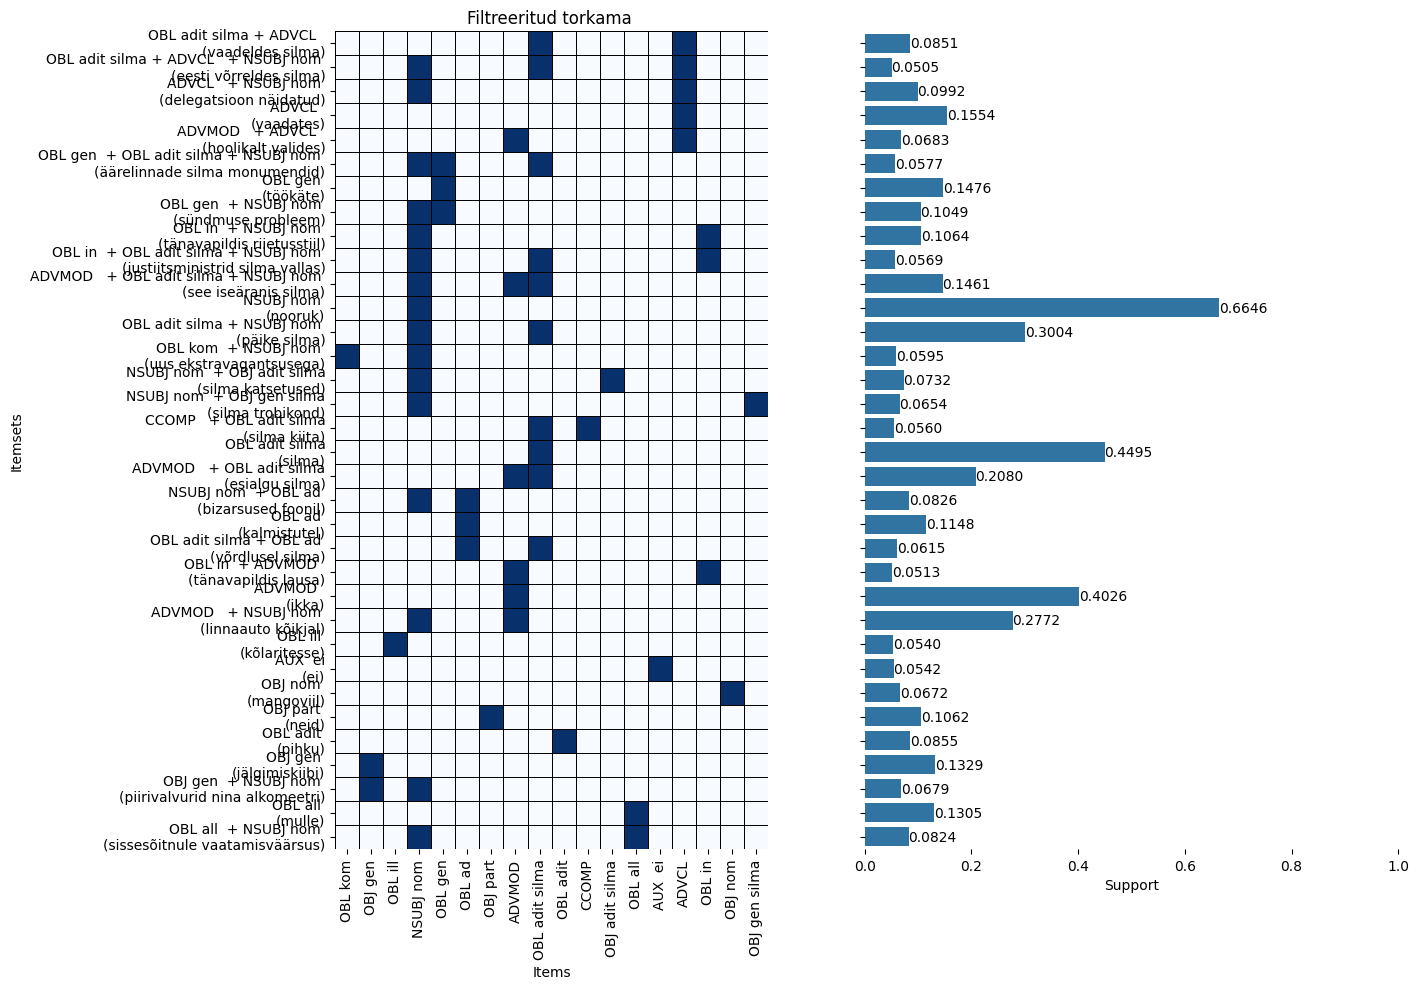

In [9]:
result = v30.make_all(verb='torkama', verb_compound='', examples=True)


************************************************ liigutama   ************************************************
Ridu analüüsimiseks: 3048
apriori min_support: 0.05
delta: 0.03
percent: 50


,support,itemsets,example,drop,drop_reason,length
6,0.693241,"((OBJ, part, ))",neljandikku,False,,1
4,0.657152,"((NSUBJ, nom, ))",ma,False,,1
18,0.453084,"((NSUBJ, nom, ), (OBJ, part, ))",te mehikesi,False,,2
1,0.404528,"((ADVMOD, , ))",mõnikord ikka,False,,1
15,0.267388,"((ADVMOD, , ), (OBJ, part, ))",ka ennast veel,False,,2
14,0.262467,"((ADVMOD, , ), (NSUBJ, nom, ))",kas ta,False,,2
3,0.190945,"((AUX, , ei))",ei,False,,1
25,0.176181,"((NSUBJ, nom, ), (ADVMOD, , ), (OBJ, part, ))",kes tegelikult asju,False,,3
16,0.145341,"((AUX, , ei), (NSUBJ, nom, ))",ei mured,False,,2
17,0.113845,"((AUX, , ei), (OBJ, part, ))",ei intressimäärasid,True,(row 26) delta: abs(0.0896 - 0.1138) < 0.03 %: (0.1138-0.0896)/0.0896*100<50,2


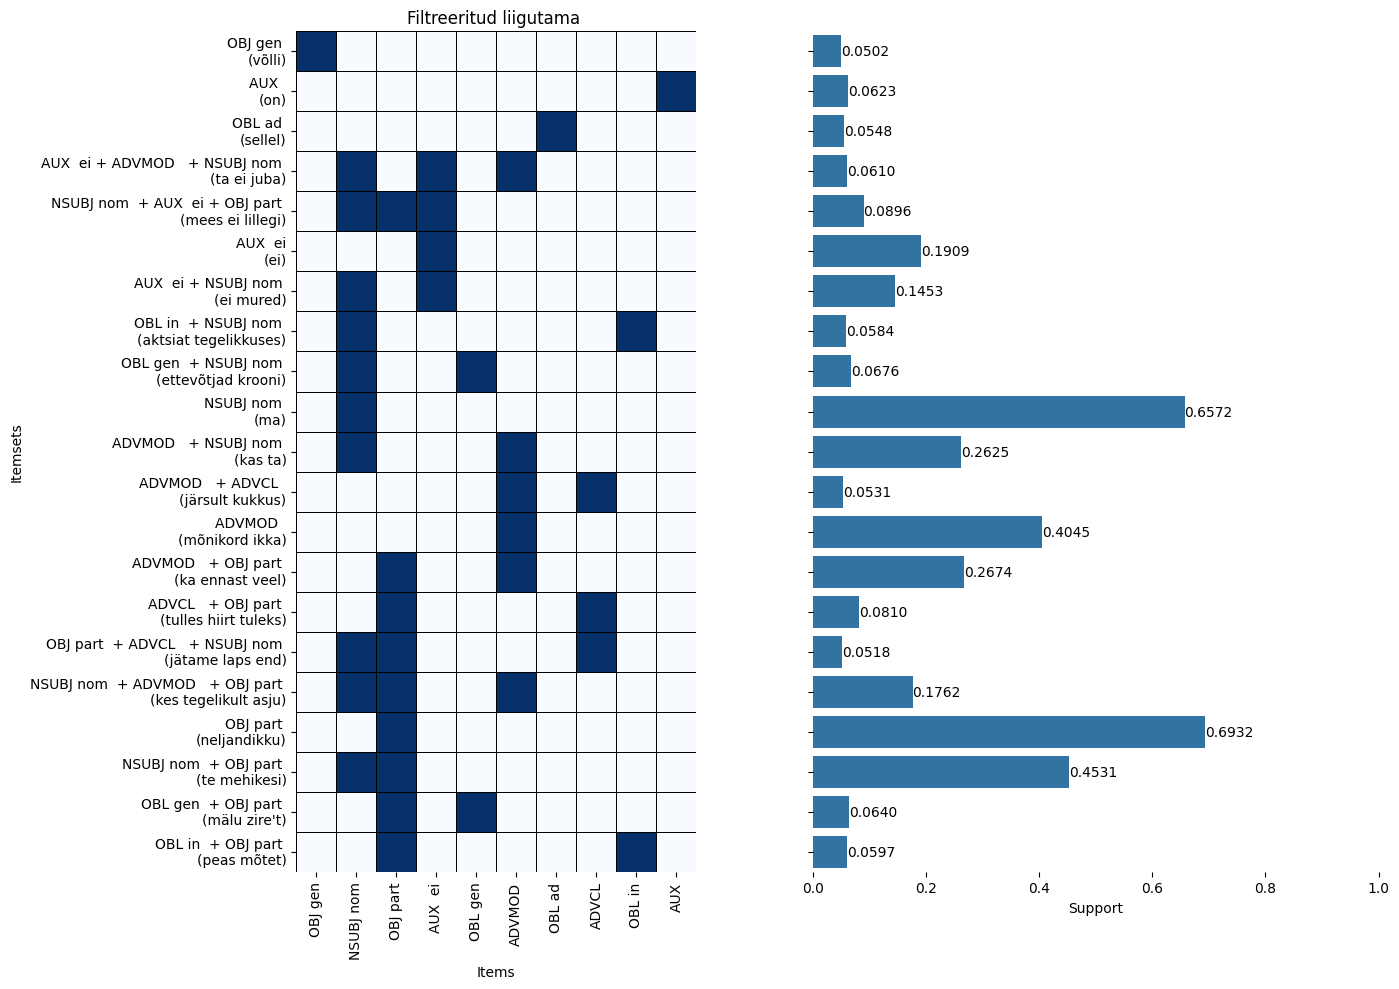

In [10]:
result = v30.make_all(verb='liigutama', verb_compound='', examples=True)